<font color='blue'> **01 _____** </font> https://pages.nist.gov/fipy/en/latest/generated/examples.diffusion.mesh1D.html#module-examples.diffusion.mesh1D   <br>
<font color='red'> **01 _____** </font> E:\15_REPOS\d01_fipy	<br>	$ python examples/diffusion/mesh1D.py

In [1]:
from fipy import CellVariable, Grid1D, Grid2D, ExplicitDiffusionTerm, DiffusionTerm , Variable ,FaceVariable            # ; from OBJviewers import Beta_Viewer.py
from fipy.tools import numerix  ; import numpy as np  ; import matplotlib.pyplot as plt   ; from scipy.special import erf

import sys  ; import os ; from importlib.metadata import entry_points   ; from OBJterms import TransientTerm              ; import fipy as fp

<font color='black'> **REF** <br>
<font color='black'> 
$ 
\,\,\,\,\,\,\,      \frac{\partial \phi}{\partial t} = D \nabla^2 \phi  \,\,\,\,\,\ [24.1]    \,\,\,\,\,\,\ \phi = 0      \,\,\,\,\,\,\  t = 0  \,\,\,\,\,\,\  
$
<font color='green'> 
$ 
\,\,\,\,\,\,\,      \phi =     \begin{cases}    0& \text{at \(x = 1\),} \\  1& \text{at \(x = 0\).}     \end{cases} 
$
<font color='orange'> 
$ 
\,\,\,\,\,\,\,      \,\,\,\,\,\,\,        
\,\,\,\,\,\,\,      \vec{n} \cdot (D \nabla \phi) \rvert_\text{Faces} = 0       
\,\,\,\,\,\,\,       BC \ noflux 
$
<font color='blue'> 
$ 
\,\,\,\,\,\,\,      \,\,\,\,\,\,\,
\,\,\,\,\,\,\,      \phi=1-\operatorname{erf}\left({\frac{x}{\,2{\sqrt{D t}}\,}}\right)
$
<font color='red'> 
$ 
\,\,\,\,\,\,\,      \Delta t\leq\Delta x^{2}/(2D).
$

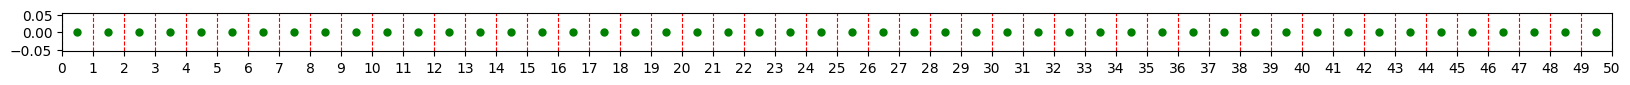

In [2]:
nx=50 ;dx=1.  ; mesh=Grid1D(nx=nx,dx=dx)                              
plt.figure(figsize=(20, 0.5))                                         ; FF = mesh.faceCenters()         ; X=mesh.faceCenters[0] ;plt.xlim(FF.min(),FF.max());plt.xticks(X)
plt.plot  (mesh.cellCenters(), np.zeros_like(mesh.cellCenters()), 'o-', markersize=5,color='green')     ; plt.grid(True, axis='x', linestyle='--', color='red') ;

In [3]:
phi = CellVariable(name="solution variable",mesh=mesh,value=0.)  #; print(mesh.cellCenters[0,40:])
D = 1.        ; valueLeft=1;phi.constrain(valueLeft, mesh.facesLeft)  ; valueRight = 0                  ; phi.constrain(valueRight, mesh.facesRight)   

In [4]:
timeStepDuration = 0.9 * dx**2 / (2 * D)                 ; steps = 100
phiAnalytical = CellVariable(name="analytical value",mesh=mesh) ; x = mesh.cellCenters[0] ;t = timeStepDuration * steps               
phiAnalytical.setValue(1 - erf(x / (2 * numerix.sqrt(D * t))))  ; YY=phiAnalytical.value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))  #plt.figure(figsize=(3,2));plt.plot(XX,YY);plt.grid(True);plt.show()

In [5]:
%%capture
def Viewer(vars, title=None, limits={}, **kwlimits):
    viewers = []     ; vars = [var for var in vars if var.mesh.numberOfCells > 0]    ; enpts = sorted(entry_points(group="fipy.viewers"))
    for ep in enpts:
        ViewerClass = ep.load()  ;fig, ax = plt.subplots(figsize=(3, 2))  ;viewer=ViewerClass(vars=vars,title=title,axes=ax,limits=limits,**kwlimits);viewers.append(viewer)
        break
    return viewers[0]
viewer = Viewer(vars=(phi, phiAnalytical),datamin=0., datamax=1.)

In [6]:
eqX = TransientTerm() == ExplicitDiffusionTerm(coeff=D) 
eqI = TransientTerm() == DiffusionTerm(coeff=D)              ; phi.setValue(valueRight)         ; timeStepDuration *= 10   ; steps //= 10

In [7]:
#for step in range(steps):       eqX.solve(var=phi,dt=timeStepDuration)  ; viewer.plot()         # Explicit ____________________________________________
#for step in range(steps):       eqI.solve(var=phi,dt=timeStepDuration)  ; viewer.plot()         # Implicit ____________________________________________
n='n'                                                       ; phi.setValue(valueRight)          ; eqCN = eqX + eqI        
#for step in range(steps - 1):
#    eqCN.solve(var=phi, dt=timeStepDuration)    ;     viewer.plot()
#    eqI.solve(var=phi, dt=timeStepDuration)     ;     viewer.plot()

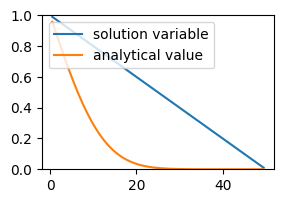

In [8]:
DiffusionTerm(coeff=D).solve(var=phi)       ; viewer.plot()       # $  D \nabla^2 \phi = 0

In [9]:
L = nx * dx
print(phi.allclose(valueLeft + (valueRight - valueLeft) * x / L, rtol = 1e-10, atol = 1e-10))

True


<font color='black'> **REF** <br>
<font color='red'> 
$ 
   D \nabla^2 \phi = 0      
$
<font color='orange'> 
$ 
\,\,\,\,\,\,\,\,\,\,\  
\phi = \begin{cases}    (1 + \sin t) / 2 &\text{on \( x = 0 \)} \\      0 &\text{on \( x = L \)} \\       \end{cases}
$
<font color='blue'> 

In [10]:
time = Variable();  del phi.faceConstraints
valueLeft = 0.5 * (1 + numerix.sin(time))   ; phi.constrain(valueLeft, mesh.facesLeft)             ; phi.constrain(0., mesh.facesRight)

eqI = TransientTerm() == DiffusionTerm(coeff=D)         ; dt = .1
while time() < 15:      time.setValue(time() + dt)      ; eqI.solve(var=phi, dt=dt)         #___________________________________________ ; viewer.plot()

<font color='black'> **REF** <br>
<font color='red'> 
$
\,\,\,\,\,\,\,\,\,\,\  
\nabla \cdot ( D \nabla \phi) = 0,
$
<font color='blue'> 
$ 
\,\,\,\,\,\,\,\,\,\,\
D = \begin{cases}
1& \text{for \( 0 < x < L / 4 \),} \\
0.1& \text{for \( L / 4 \le x < 3 L / 4 \),} \\
1& \text{for \( 3 L / 4 \le x < L \),}
\end{cases}
$
<font color='black'> 
$ 
\,\,\,\,\,\,\,\,\,\,\
\phi = 0    \ \ at \ \  x = 0     \quad   D \frac{\partial \phi}{\partial x}= 1  \ \ \ x = L
$
<font color='brow'> 
$ 
\,\,\,\,\,\,\,\,\,\,\
D \frac{\partial \phi}{\partial x}= 1  \ \ at \ \ x = L
$

In [11]:
D = FaceVariable(mesh=mesh, value=1.0)  ; D.setValue(0.1, where=(L/4.  <=X)&(X<  3.*L/4.))                      ; phi = CellVariable(mesh=mesh, name="solution variable")
valueLeft = 0.      ; phi.constrain(valueLeft, mesh.facesLeft)                                ; gradRight = 1.  ; phi.faceGrad.constrain([gradRight], mesh.facesRight)
phi.setValue(0)     ; eq = DiffusionTerm(coeff=D)     ; solver = eq.getDefaultSolver(tolerance=1e-7)            ; eq.solve(var=phi, solver=solver)

<Figure size 640x480 with 0 Axes>

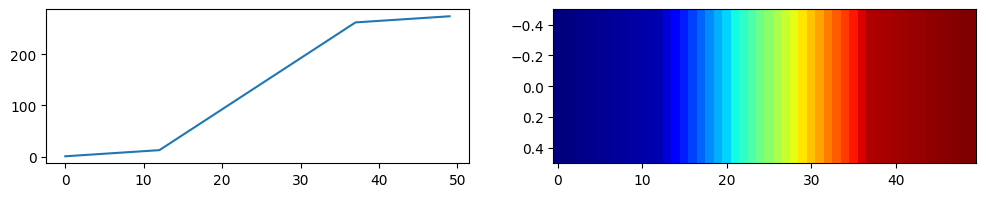

In [12]:
YY=phi.value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))           ; DD = YY.reshape(1, -1)
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 2))             ; ax1.plot(XX,YY)          ; ax2.imshow(DD, cmap='jet', aspect='auto'); plt.show()

<font color='black'> **REF** <br>
<font color='black'> 
$ 
\,\,\,\,\,\,\,      \frac{\partial \phi}{\partial t} = D \nabla^2 \phi  \,\,\,\,\,\ [24.1]    
$
<font color='red'> 
$
\,\,\,\,\,\  
\frac{\partial}{\partial t}\left(\rho\hat{C}_{p}\phi\right)=\nabla\cdot[k\nabla\phi]
$
<font color='blue'> 
$
\,\,\,\,\,\  
. .. \ D \ . .. = \alpha={\frac{k}{\rho{\bar{C}}_{p}}}
$
<font color='red'> 
$
\,\,\,\,\,\     \,\,\,\,\,\     \,\,\,\,\,\     \,\,\,\,\,\         \,\,\,\,\,\     \,\,\,\,\,\ 
\frac{\partial\phi}{\partial t}=\nabla\cdot[D(\phi)\nabla\phi]
$
<font color='orange'> 
$
\,\,\,\,\,\     \,\,\,\,\,\      
D=D_{0}(1-\phi)
$
<font color='black'> 
$
\,\,\,\,\,\
\phi(x)=1-\sqrt{\frac{x}{L}}
$

In [13]:
phiT = CellVariable(name="correct", mesh=mesh)      ; phiT.faceGrad.constrain([gradRight], mesh.facesRight)     ; phiT.constrain(valueLeft, mesh.facesLeft) ; phiT.setValue(0)
phiF = CellVariable(name="incorrect", mesh=mesh)    ; phiF.faceGrad.constrain([gradRight], mesh.facesRight)     ; phiF.constrain(valueLeft, mesh.facesLeft) ; phiF.setValue(0)

k = 1.  ; X = mesh.faceCenters[0]                   ; alpha_false = FaceVariable(mesh=mesh, value=1.0)    ; alpha_false.setValue(0.1, where=(L/4. <=X)&(X< 3.*L/4.))
eqF = 0 == DiffusionTerm(coeff=alpha_false)                                                               ; eqF.solve(var=phiF)
eqT = 0 == DiffusionTerm(coeff=k)                   ; solver = eqT.getDefaultSolver(tolerance=1e-7)       ; eqT.solve(var=phiT, solver=solver)
# _________________________________________________ x = mesh.cellCenters[0] ; phiAnalytical.setValue(x) ; print(phiT.allclose(phiAnalytical, atol=1e-8, rtol=1e-8)) # __________
YY=phiT.value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))      ; plt.figure(figsize=(3,2))  # ; plt.plot(XX,YY,label='True');plt.grid(True);plt.legend()
YY=phiF.value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))                                   # ; plt.plot(XX,YY,label='False');plt.grid(True);plt.legend() ;plt.show(); 

<Figure size 300x200 with 0 Axes>

In [14]:
valueLeft = 1. ; valueRight = 0.                                           ; phi = [CellVariable(name="solution variable",mesh=mesh,value=valueRight    ,hasOld=1),
CellVariable(name="1 sweep" ,mesh=mesh) ,CellVariable(name="2 sweeps",mesh=mesh),CellVariable(name="3 sweeps",mesh=mesh) ,CellVariable(name="4 sweeps",mesh=mesh)]

D0 = 1.     ; eq = TransientTerm() == DiffusionTerm(coeff=D0 * (1 - phi[0]))     ; phi[0].constrain(valueRight, mesh.facesRight)       ; phi[0].constrain(valueLeft, mesh.facesLeft)   
x = mesh.cellCenters[0]  ; phiAnalytical.setValue(1. - numerix.sqrt(x/L))        #; viewer = Viewer(vars=phi + [phiAnalytical],datamin=0., datamax=1.)

In [15]:
for swEEps in range(len(phi)):  
    phi[0].setValue(valueRight)
    for _ in range(steps):       
        phi[0].updateOld()
        for _ in range(swEEps):   n='n';    res = eq.sweep(var=phi[0],dt=timeStepDuration)
    phi[swEEps].setValue(phi[0])

res: 2.05e-06


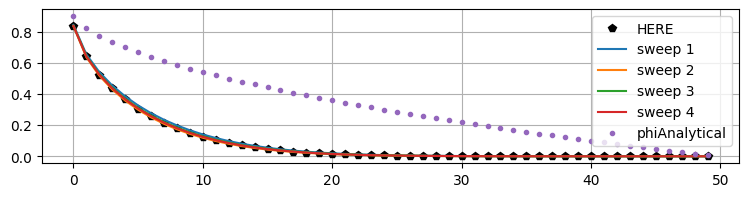

In [16]:
YY=phi[0].value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))      ; plt.figure(figsize=(9,2))  ; plt.plot(XX,YY,'p',color='k',label='HERE');plt.grid(True);plt.legend()
YY=phi[1].value                                                                             ; plt.plot(XX,YY,label='sweep 1');plt.grid(True);plt.legend() 
YY=phi[2].value                                                                             ; plt.plot(XX,YY,label='sweep 2');plt.grid(True);plt.legend()  
YY=phi[3].value                                                                             ; plt.plot(XX,YY,label='sweep 3');plt.grid(True);plt.legend() 
YY=phi[4].value                                                                             ; plt.plot(XX,YY,label='sweep 4');plt.grid(True);plt.legend() ; print('res:',f"{res:.2e}")
YY=phiAnalytical.value                                                                      ; plt.plot(XX,YY,'.',label='phiAnalytical');plt.grid(True);plt.legend() ;plt.show(); 

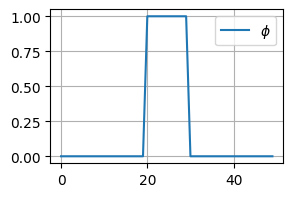

In [17]:
phi = CellVariable(mesh=mesh, name=r"$\phi$")       ; phi.value = 0.  ; phi.setValue(1., where=(x > L/2. - L/10.) & (x < L/2. + L/10.))       # implicit SOL pitfall !
plt.figure(figsize=(3,2))           ; YY=phi.value   ;XX=np.linspace(0,len(YY)-1,num=len(YY)); plt.plot(XX,YY,label='$\phi$');plt.grid(True);plt.legend() ;plt.show(); 

In [18]:
D = 1.      ; eq = TransientTerm() == DiffusionTerm(D)      ; dt = 10. * dx**2 / (2 * D)        ; steps = 200

In [19]:
%%capture
def Viewer(vars, title=None, limits={}, **kwlimits):
    viewers = []     ; vars = [var for var in vars if var.mesh.numberOfCells > 0]    ; enpts = sorted(entry_points(group="fipy.viewers"))
    for ep in enpts:
        ViewerClass = ep.load()  ;fig, ax = plt.subplots(figsize=(3, 2))  ;viewer=ViewerClass(vars=vars,title=title,axes=ax,limits=limits,**kwlimits);viewers.append(viewer)
        break
    return viewers[0]
viewer = Viewer(vars=(phi, ),datamin=0., datamax=1.)

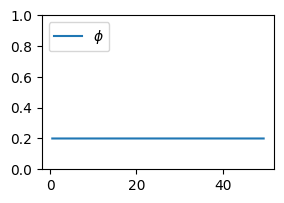

[0.19996443 0.19996499 0.1999661  0.19996775 0.1999699 ]


In [20]:
for step in range(steps):       eq.solve(var=phi, dt=dt)        ; viewer.plot(); print(phi[:5])

In [21]:
'''fig, (ax1) = plt.subplots(1, 1,figsize=(12, 2))
for step in range(steps):       
    eq.solve(var=phi, dt=dt)        
    DD = phi.value.reshape(1, -1)
    ax2.imshow(DD, cmap='jet', aspect='auto')
plt.show()'''

"fig, (ax1) = plt.subplots(1, 1,figsize=(12, 2))\nfor step in range(steps):       \n    eq.solve(var=phi, dt=dt)        \n    DD = phi.value.reshape(1, -1)\n    ax2.imshow(DD, cmap='jet', aspect='auto')\nplt.show()"

In [20]:
phi.value = 0.          ; phi.setValue(1., where=(x > L/2. - L/10.) & (x < L/2. + L/10.))

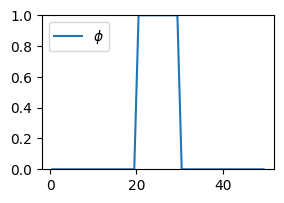

In [21]:
try:    DiffusionTerm(coeff=D).solve(var=phi)
except:
    pass
    viewer.plot()

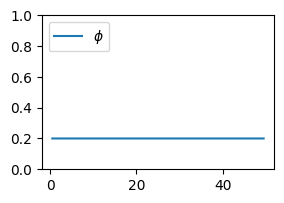

In [22]:
eq = (TransientTerm() == DiffusionTerm(D))          ; solver = eq.getDefaultSolver(criterion="initial", tolerance=1e-9)          ; TIME = 1e6
eq.solve(var=phi, dt=TIME*dt, solver=solver)        ; viewer.plot()